<a href="https://colab.research.google.com/github/Rudra-CSER/Ai-Education_analyzer_model/blob/main/XGBoost_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()  # Upload all your CSVs one by one


Saving All csvs.zip to All csvs.zip


In [ ]:
pip install xgboost

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, LeaveOneOut
from sklearn.metrics import mean_squared_error, r2_score


In [ ]:
final   = pd.read_csv("final_education_dataset.csv")
pisa    = pd.read_csv("pisa_score.csv")
teacher = pd.read_csv("teacher_quality.csv")
stress  = pd.read_csv("stress_performance.csv")
skill   = pd.read_csv("skill_assessment.csv")
employ  = pd.read_csv("education_vs_employability.csv")
secondary = pd.read_csv("education_data_secondary.csv")

# Strip whitespace from column names
for df in [final, pisa, teacher, stress, skill, employ, secondary]:
    df.columns = df.columns.str.strip()

# Merge all on 'country'
df = final \
    .merge(pisa, on='country') \
    .merge(teacher[['country','teacher_selection','training_model','retention']], on='country') \
    .merge(stress[['country','exam_frequency','private_tutoring']], on='country') \
    .merge(skill[['country','assessment_flexibility','critical_thinking','practical_learning']], on='country') \
    .merge(employ[['country','industry_alignment','job_readiness','innovation_focus']], on='country') \
    .merge(secondary[['country','student_teacher_ratio','enrollment']], on='country')

print(df.shape)
df.head()

(10, 22)


,country,stress,academic_pressure,teacher_quality,mental_health_support,performance,creativity,assessment_rigidity,pisa_score,teacher_selection,...,exam_frequency,private_tutoring,assessment_flexibility,critical_thinking,practical_learning,industry_alignment,job_readiness,innovation_focus,student_teacher_ratio,enrollment
0,India,9,9,5,3,5,4,9,4,4,...,9,10,3,4,4,5,5,5,7,6
1,Finland,2,2,10,10,8,10,2,7,10,...,2,2,10,10,9,9,9,9,2,9
2,USA,6,6,6,8,6,7,6,5,6,...,6,3,6,7,7,7,7,8,5,8
3,UK,6,6,8,8,6,8,6,5,8,...,6,3,7,8,7,8,8,8,4,8
4,Singapore,9,9,10,6,10,6,9,10,10,...,9,8,5,7,7,10,10,10,3,9


In [ ]:
X = df.drop(columns=['country', 'performance'])
y = df['performance']

print("Features:", X.columns.tolist())
print("Target:", y.values)

Features: ['stress', 'academic_pressure', 'teacher_quality', 'mental_health_support', 'creativity', 'assessment_rigidity', 'pisa_score', 'teacher_selection', 'training_model', 'retention', 'exam_frequency', 'private_tutoring', 'assessment_flexibility', 'critical_thinking', 'practical_learning', 'industry_alignment', 'job_readiness', 'innovation_focus', 'student_teacher_ratio', 'enrollment']
Target: [ 5  8  6  6 10 10 10 10  8  7]


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [2, 3],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=LeaveOneOut(),          # Best CV method for only 10 rows
    scoring='neg_mean_squared_error',
    verbose=1
)

grid_search.fit(X_scaled, y)
print("Best Parameters:", grid_search.best_params_)
best_model = grid_search.best_estimator_

Fitting 10 folds for each of 32 candidates, totalling 320 fits
Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 50, 'subsample': 0.8}


In [ ]:
y_pred = best_model.predict(X_scaled)

print(f"R² Score : {r2_score(y, y_pred):.4f}")
print(f"MSE      : {mean_squared_error(y, y_pred):.4f}")

results = pd.DataFrame({
    'Country'  : df['country'],
    'Actual'   : y.values,
    'Predicted': y_pred.round(2)
})
print(results)

R² Score : 0.9951
MSE      : 0.0168
       Country  Actual  Predicted
0        India       5       5.25
1      Finland       8       7.96
2          USA       6       5.94
3           UK       6       6.04
4    Singapore      10       9.97
5  South Korea      10      10.03
6        China      10       9.73
7        Japan      10       9.94
8       Canada       8       8.11
9      Germany       7       7.07


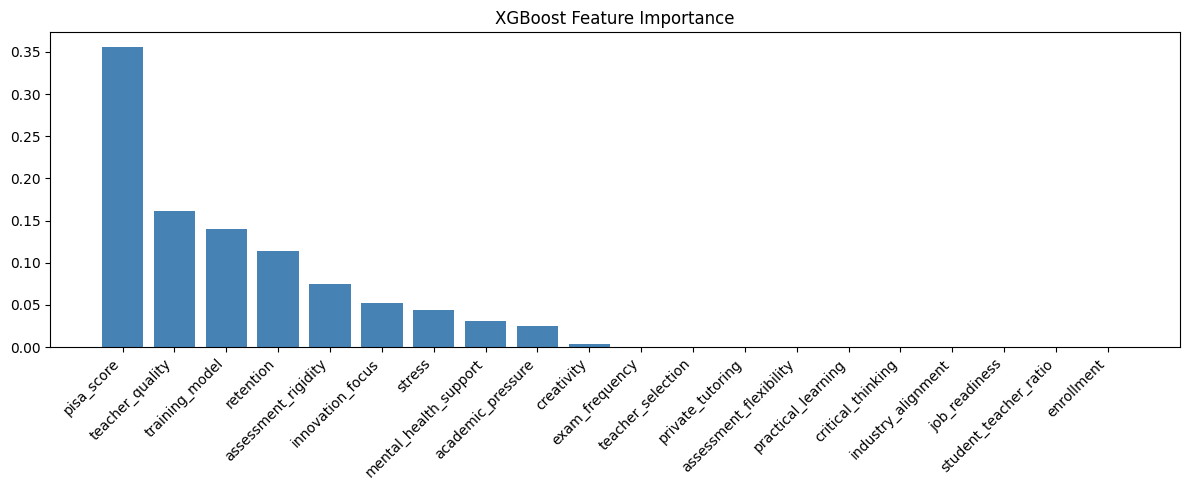

                   Feature  Importance
6               pisa_score    0.355362
2          teacher_quality    0.161716
8           training_model    0.139392
9                retention    0.113994
5      assessment_rigidity    0.074641
17        innovation_focus    0.051909
0                   stress    0.044300
3    mental_health_support    0.030573
1        academic_pressure    0.024704
4               creativity    0.003409
10          exam_frequency    0.000000
7        teacher_selection    0.000000
11        private_tutoring    0.000000
12  assessment_flexibility    0.000000
14      practical_learning    0.000000
13       critical_thinking    0.000000
15      industry_alignment    0.000000
16           job_readiness    0.000000
18   student_teacher_ratio    0.000000
19              enrollment    0.000000


In [ ]:
importances = best_model.feature_importances_
feat_df = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': importances
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 5))
plt.bar(feat_df['Feature'], feat_df['Importance'], color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.title('XGBoost Feature Importance')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

print(feat_df)

In [ ]:
joblib.dump(best_model, 'xgboost_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Model saved!")

# Download to your PC
files.download('xgboost_model.pkl')
files.download('scaler.pkl')
files.download('feature_importance.png')

Model saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
def predict_performance(input_dict):
    input_df = pd.DataFrame([input_dict])
    input_scaled = scaler.transform(input_df)
    score = best_model.predict(input_scaled)[0]
    return round(float(score), 2)

# Example — what if India reduces stress?
example = {
    'stress': 4, 'academic_pressure': 4, 'teacher_quality': 8,
    'mental_health_support': 7, 'creativity': 7, 'assessment_rigidity': 5,
    'pisa_score': 5, 'teacher_selection': 6, 'training_model': 6,
    'retention': 6, 'exam_frequency': 4, 'private_tutoring': 5,
    'assessment_flexibility': 6, 'critical_thinking': 7, 'practical_learning': 7,
    'industry_alignment': 6, 'job_readiness': 6, 'innovation_focus': 6,
    'student_teacher_ratio': 6, 'enrollment': 7
}

print("Predicted Performance Score:", predict_performance(example))

Predicted Performance Score: 6.51
